# PROYECTO FINAL ML — CLASIFICADOR DE MEMORIA JERÁRQUICA PARA AGENTES IA
# Tesis: Arquitectura de Memoria Jerárquica para Agentes de IA


## SECCIÓN 0 — INSTALACIÓN Y SETUP

In [1]:
# Instalación de dependencias
# Ejecutar esta celda una sola vez al inicio del entorno de Colab.
# sentence-transformers : embeddings multilingüe (Técnica B)
# optuna                : optimización bayesiana de hiperparámetros (extra)
# wordcloud             : nubes de palabras para EDA

!pip install -q sentence-transformers optuna wordcloud
print("✅ Dependencias instaladas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.7 MB/s eta 0:00:00
✅ Dependencias instaladas correctamente.


In [2]:
# Imports globales

# Utilidades generales
import warnings
import random
import os

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# NLP / texto
import re
from collections import Counter

# Suprimir warnings para una salida limpia
warnings.filterwarnings('ignore')

In [3]:
# Configuración global (seed y estética)

# Fijamos la semilla global para reproducibilidad total del experimento
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paleta de colores consistente para las 3 clases
# Cada color representa intuitivamente el tipo de memoria:
#   Azul  → Trabajo   (activo, presente, concreto)
#   Naranja → Episódica (eventos pasados, calidez temporal)
#   Verde → Semántica  (conocimiento, naturaleza, estabilidad)
PALETTE = {
    'Memoria de trabajo': '#4A90D9',
    'Memoria episódica':  '#E8874A',
    'Memoria semántica':  '#45B08C',
}
CLASS_ORDER = ['Memoria de trabajo', 'Memoria episódica', 'Memoria semántica']
COLORS     = [PALETTE[c] for c in CLASS_ORDER]

# Estética global de matplotlib / seaborn
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi':       130,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9.5,
    'ytick.labelsize':  9.5,
    'legend.fontsize':  9.5,
})

print("✅ Configuración global aplicada.")
print(f"   Semilla global: {SEED}")
print(f"   Clases objetivo: {CLASS_ORDER}")

✅ Configuración global aplicada.
   Semilla global: 42
   Clases objetivo: ['Memoria de trabajo', 'Memoria episódica', 'Memoria semántica']


# SECCIÓN 1 — INTRODUCCIÓN

## Proyecto Final: Clasificador de Memoria Jerárquica para Agentes de IA

### Contexto
Este proyecto es un **piloto práctico** enmarcado en la tesis titulada:
> *"Arquitectura de Memoria Jerárquica para Agentes de IA: Mejoramiento del
> Proceso de Inferencia sin Dependencia del Historial Completo"*

### Objetivo del Clasificador
Dado el texto de entrada de un usuario, el clasificador debe decidir a cuál
de las **tres capas de memoria** del agente debe acceder:

| Clase | Tipo de Memoria | Descripción |
|-------|----------------|-------------|
| **0** | 🔵 Memoria de trabajo | Contexto inmediato de la conversación activa |
| **1** | 🟠 Memoria episódica | Resúmenes y eventos de sesiones anteriores |
| **2** | 🟢 Memoria semántica | Hechos genéricos, preferencias y conocimiento consolidado |

### Estrategia Metodológica
Compararemos **dos técnicas** de forma estadísticamente rigurosa:
- **Técnica A (Baseline):** TF-IDF + Regresión Logística
- **Técnica B (Transfer Learning):** Sentence Embeddings Multilingüe + Regresión Logística

La comparación se realizará con **Repeated Stratified K-Fold** y un test
de hipótesis pareado (**T-test pareado o Wilcoxon signed-rank**, según la normalidad de los scores) para determinar si la diferencia
entre técnicas es estadísticamente significativa.

# SECCIÓN 2 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [5]:
# Carga y vista general del dataset

# Cargamos el dataset — asumimos que fue subido a Colab con este nombre
df = pd.read_csv('dataset_intenciones_memoria.csv')

print("=" * 60)
print("  VISTA GENERAL DEL DATASET")
print("=" * 60)
print(f"\n📐 Dimensiones : {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"📋 Columnas    : {df.columns.tolist()}")
print(f"🔍 Tipos       :\n{df.dtypes.to_string()}")
print(f"\n❓ Valores nulos:\n{df.isnull().sum().to_string()}")
print("\n📄 Primeras 5 filas:")
print(df.head().to_string(index=False))

  VISTA GENERAL DEL DATASET

📐 Dimensiones : 150 filas × 2 columnas
📋 Columnas    : ['texto', 'etiqueta']
🔍 Tipos       :
texto       object
etiqueta    object

❓ Valores nulos:
texto       0
etiqueta    0

📄 Primeras 5 filas:
                                                               texto           etiqueta
¿Te acuerdas de la estrategia de marketing que platicamos el martes?  Memoria episódica
                            ¿Por qué pusiste esa condición en el if? Memoria de trabajo
                        Dame la fórmula química del ácido sulfúrico.  Memoria semántica
           Básate en el presupuesto que calculamos hace quince días.  Memoria episódica
         Ayer me sugeriste tres películas, ¿cuál era la de suspenso?  Memoria episódica


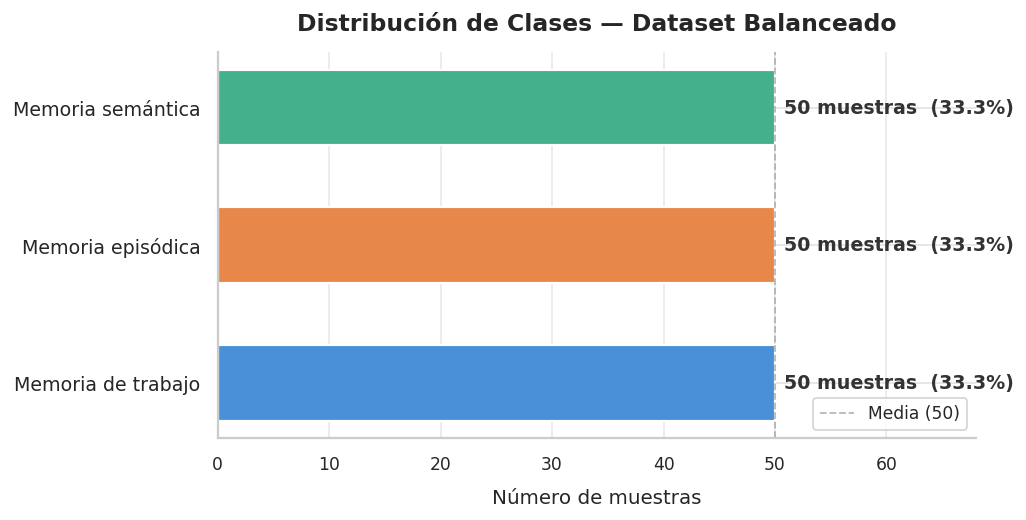


✅ Figura 1 — Distribución de clases generada.


In [6]:
# Distribución de clases

# Conteo y porcentaje por clase
class_counts = (
    df['etiqueta']
    .value_counts()
    .reindex(CLASS_ORDER)        # Orden fijo para consistencia visual
)
class_pct = (class_counts / class_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.2))

bars = ax.barh(
    y=CLASS_ORDER,
    width=class_counts.values,
    color=COLORS,
    height=0.55,
    edgecolor='white',
    linewidth=1.2,
)

# Etiquetas dentro y fuera de las barras
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{count} muestras  ({pct}%)',
        va='center', ha='left',
        fontsize=10.5, fontweight='bold',
        color='#333333',
    )

ax.set_xlim(0, class_counts.max() + 18)
ax.set_xlabel('Número de muestras', labelpad=8)
ax.set_title('Distribución de Clases — Dataset Balanceado', fontweight='bold', pad=12)
ax.axvline(x=class_counts.mean(), color='#999999', linestyle='--',
           linewidth=1, alpha=0.7, label=f'Media ({int(class_counts.mean())})')
ax.legend(loc='lower right')
ax.set_yticklabels(CLASS_ORDER, fontsize=10.5)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('eda_01_distribucion_clases.png', bbox_inches='tight')
plt.show()
print("\n✅ Figura 1 — Distribución de clases generada.")

  ESTADÍSTICAS DE LONGITUD TEXTUAL POR CLASE
                   n_chars               n_palabras             
                      mean   std min max       mean  std min max
etiqueta                                                        
Memoria de trabajo    43.2   9.8  15  59        7.6  1.7   3  11
Memoria episódica     61.2   6.1  47  73       10.6  1.0   8  13
Memoria semántica     53.7  13.0  26  78        9.2  2.1   5  13


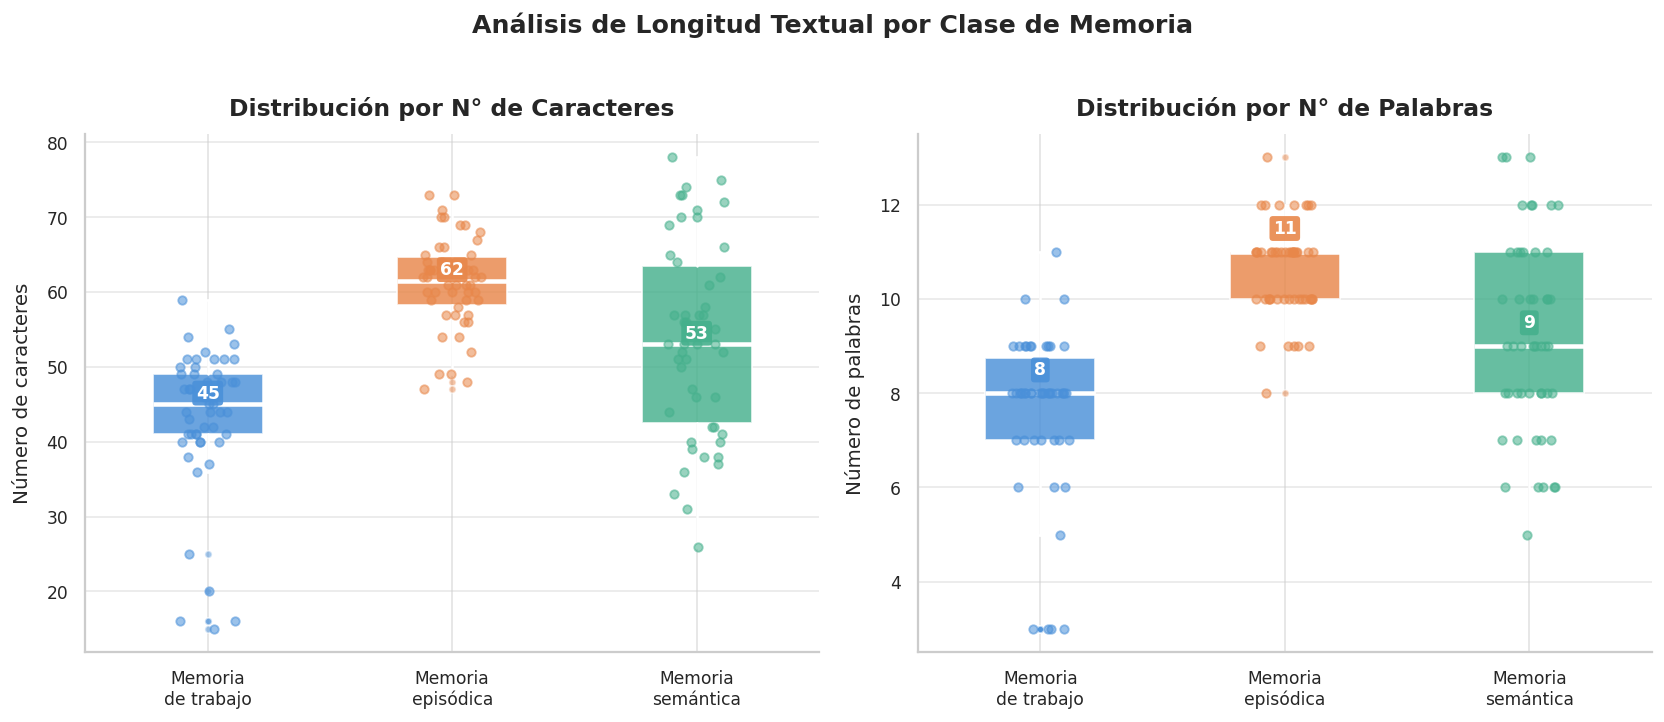


✅ Figura 2 — Longitud de textos generada.


In [7]:
# Análisis de longitud de textos

# Creamos columnas con métricas de longitud para cada muestra
df['n_chars']    = df['texto'].apply(len)
df['n_palabras'] = df['texto'].apply(lambda x: len(x.split()))

# Estadísticas descriptivas de longitud por clase
print("=" * 65)
print("  ESTADÍSTICAS DE LONGITUD TEXTUAL POR CLASE")
print("=" * 65)
stats = (
    df.groupby('etiqueta')[['n_chars', 'n_palabras']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(1)
    .reindex(CLASS_ORDER)
)
print(stats.to_string())

# Figura: Boxplots + Strip plots (chars y palabras)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

METRICS = [
    ('n_chars',    'Número de caracteres',      axes[0]),
    ('n_palabras', 'Número de palabras',         axes[1]),
]

for col, ylabel, ax in METRICS:
    # Boxplot base
    bp = ax.boxplot(
        [df.loc[df['etiqueta'] == cls, col].values for cls in CLASS_ORDER],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
    )
    # Colorear los boxplots con la paleta del proyecto
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.82)
    for flier, color in zip(bp['fliers'], COLORS):
        flier.set_markerfacecolor(color)

    # Strip plot (puntos individuales) para ver la distribución real
    for i, (cls, color) in enumerate(zip(CLASS_ORDER, COLORS), start=1):
        valores = df.loc[df['etiqueta'] == cls, col].values
        # Añadir jitter horizontal aleatorio
        jitter = np.random.uniform(-0.12, 0.12, size=len(valores))
        ax.scatter(
            np.full_like(valores, i, dtype=float) + jitter,
            valores,
            color=color, alpha=0.55, s=22, zorder=3,
        )

    # Anotación de la mediana sobre cada boxplot
    for i, cls in enumerate(CLASS_ORDER, start=1):
        mediana = df.loc[df['etiqueta'] == cls, col].median()
        ax.text(i, mediana + 0.3, f'{mediana:.0f}',
                ha='center', va='bottom', fontsize=9.5,
                fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc=COLORS[i-1], alpha=0.9, lw=0))

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(
        ['Memoria\nde trabajo', 'Memoria\nepisódica', 'Memoria\nsemántica'],
        fontsize=9.5,
    )
    ax.set_ylabel(ylabel, labelpad=8)
    ax.grid(axis='y', alpha=0.4)

axes[0].set_title('Distribución por N° de Caracteres', fontweight='bold', pad=10)
axes[1].set_title('Distribución por N° de Palabras',   fontweight='bold', pad=10)

fig.suptitle('Análisis de Longitud Textual por Clase de Memoria',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_longitud_textos.png', bbox_inches='tight')
plt.show()
print("\n✅ Figura 2 — Longitud de textos generada.")

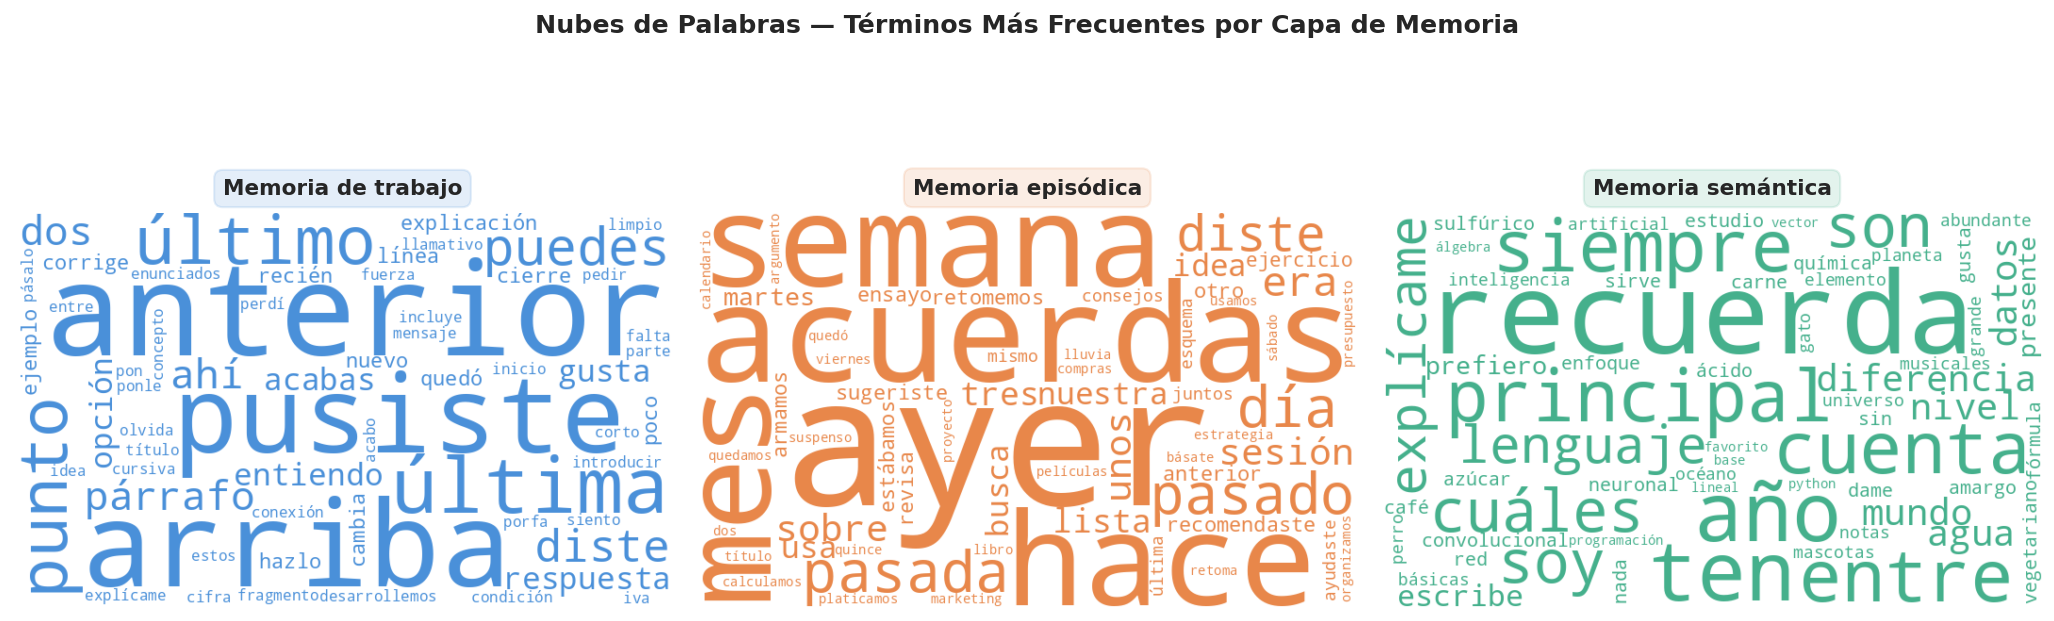


✅ Figura 3 — Nubes de palabras generadas.


In [8]:
# Nubes de palabras por clase

# Lista de stopwords en español (unión de las más comunes)
# Ajusta esta lista según las palabras vacías específicas de tu corpus
STOPWORDS_ES = {
    'de','la','el','en','que','los','las','un','una','se','con','del','por',
    'al','su','es','me','te','le','lo','nos','si','no','y','a','o','e','fue',
    'mi','tu','ya','más','pero','como','para','esto','eso','aquí','hay','han',
    'tiene','puede','esta','este','ese','esa','cuál','qué','cómo','dónde',
    'cuándo','quién','cuánto','has','había','hemos','están','tengo','tienes',
    'hacer','ser','estar','he','te','di','da','le','les','nos','vos','su','sus',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Nubes de Palabras — Términos Más Frecuentes por Capa de Memoria',
             fontsize=14, fontweight='bold', y=1.02)

for ax, cls, color in zip(axes, CLASS_ORDER, COLORS):
    # Concatenar todos los textos de la clase
    corpus = ' '.join(df.loc[df['etiqueta'] == cls, 'texto'].values).lower()

    # Tokenizar: solo letras (incluye acentos y ñ)
    tokens = re.findall(r'\b[a-záéíóúüñ]{3,}\b', corpus)
    tokens_filtrados = [t for t in tokens if t not in STOPWORDS_ES]
    texto_limpio = ' '.join(tokens_filtrados)

    # Generar la nube de palabras
    wc = WordCloud(
        width=700, height=420,
        background_color='white',
        colormap=None,              # Lo coloreamos manualmente abajo
        color_func=lambda *args, **kwargs: color,
        max_words=60,
        prefer_horizontal=0.85,
        collocations=False,         # Evitar bigramas artificiales
        random_state=SEED,
    ).generate(texto_limpio)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')

    # Título con caja de color como etiqueta visual
    ax.set_title(cls, fontsize=12, fontweight='bold', pad=10,
                 bbox=dict(boxstyle='round,pad=0.4', fc=color, alpha=0.15, lw=1.2, ec=color))

plt.tight_layout()
plt.savefig('eda_03_wordclouds.png', bbox_inches='tight')
plt.show()
print("\n✅ Figura 3 — Nubes de palabras generadas.")

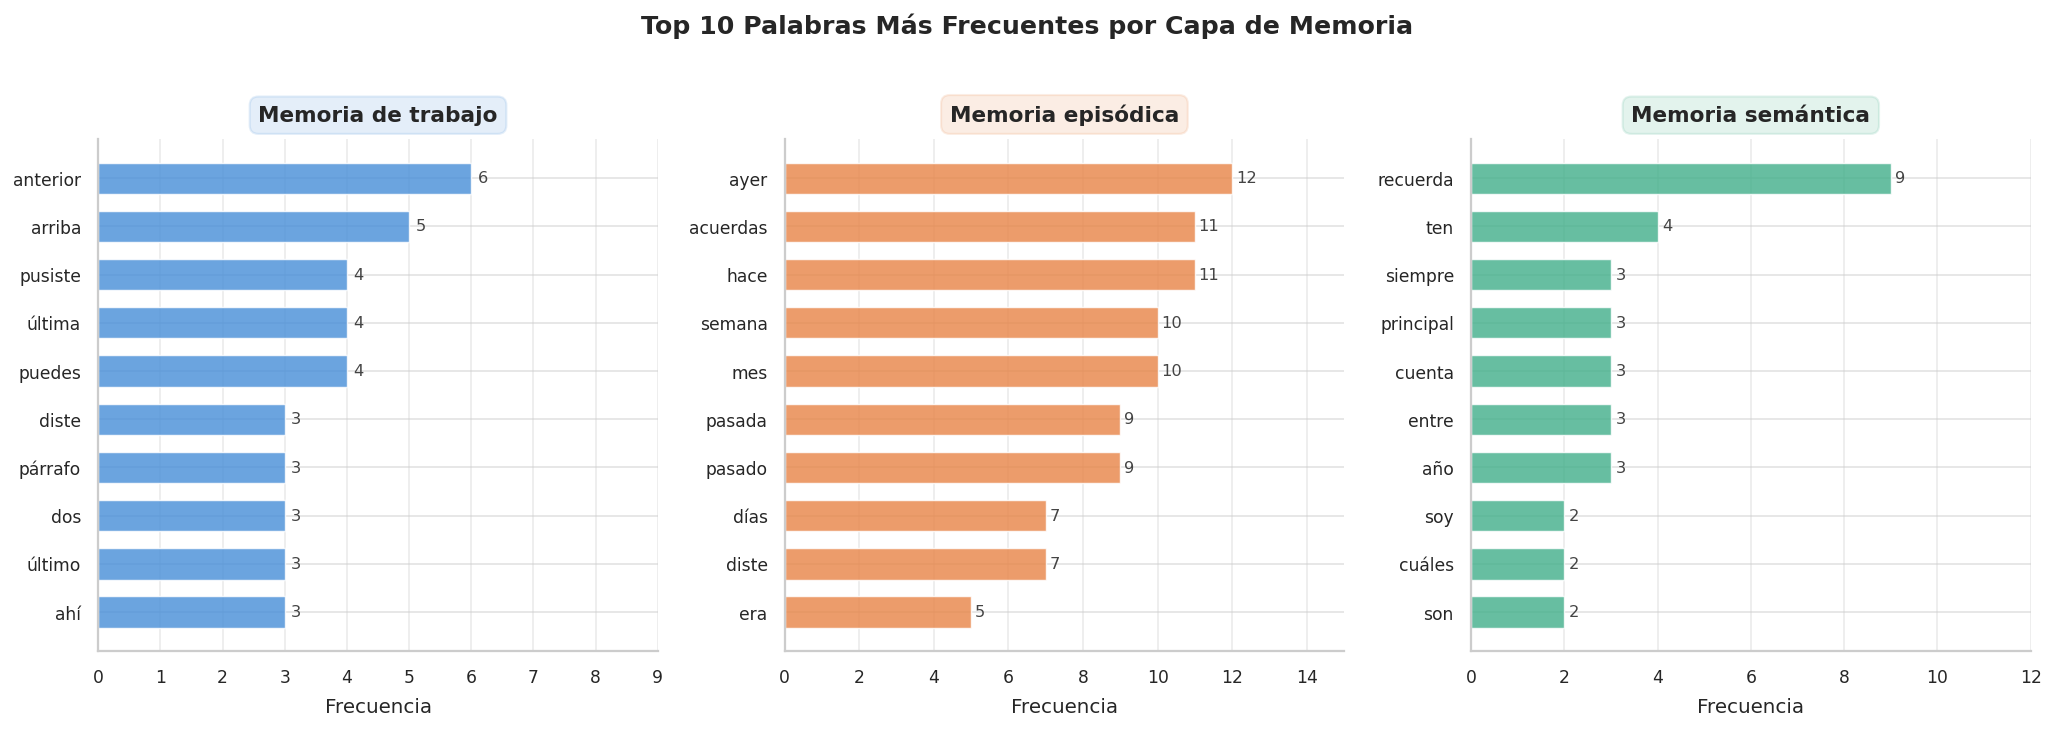


✅ Figura 4 — Top palabras por clase generadas.


In [9]:
# Top 10 palabras más frecuentes por clase

# Función auxiliar: extraer top-N palabras de una clase
def get_top_words(dataframe, clase, n=10, stopwords=STOPWORDS_ES):
    """Tokeniza, filtra stopwords y devuelve los N tokens más frecuentes."""
    corpus = ' '.join(dataframe.loc[dataframe['etiqueta'] == clase, 'texto'].values).lower()
    tokens = re.findall(r'\b[a-záéíóúüñ]{3,}\b', corpus)
    tokens_filtrados = [t for t in tokens if t not in stopwords]
    return Counter(tokens_filtrados).most_common(n)

# Gráfico de barras horizontales: Top 10 por clase
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Top 10 Palabras Más Frecuentes por Capa de Memoria',
             fontsize=14, fontweight='bold', y=1.02)

for ax, cls, color in zip(axes, CLASS_ORDER, COLORS):
    top_words = get_top_words(df, cls, n=10)
    palabras  = [w for w, _ in top_words]
    conteos   = [c for _, c in top_words]

    # Barras horizontales (invertidas para que la más frecuente quede arriba)
    bars = ax.barh(
        y=list(reversed(palabras)),
        width=list(reversed(conteos)),
        color=color,
        alpha=0.82,
        height=0.65,
        edgecolor='white',
        linewidth=0.8,
    )

    # Etiquetas de conteo al final de cada barra
    for bar, val in zip(bars, list(reversed(conteos))):
        ax.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va='center', ha='left',
            fontsize=9, color='#444444',
        )

    ax.set_xlim(0, max(conteos) + 3)
    ax.set_xlabel('Frecuencia', labelpad=6)
    ax.set_title(cls, fontsize=12, fontweight='bold', pad=10,
                 bbox=dict(boxstyle='round,pad=0.4', fc=color, alpha=0.15, lw=1.2, ec=color))
    ax.grid(axis='x', alpha=0.35)
    ax.tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
plt.savefig('eda_04_top_palabras.png', bbox_inches='tight')
plt.show()
print("\n✅ Figura 4 — Top palabras por clase generadas.")

In [10]:
# Resumen estadístico del EDA

print("=" * 60)
print("  RESUMEN ESTADÍSTICO — EDA COMPLETO")
print("=" * 60)
for cls in CLASS_ORDER:
    subset = df[df['etiqueta'] == cls]
    print(f"\n🔹 {cls}")
    print(f"   Muestras    : {len(subset)}")
    print(f"   Chars media : {subset['n_chars'].mean():.1f}  (±{subset['n_chars'].std():.1f})")
    print(f"   Palabras μ  : {subset['n_palabras'].mean():.1f}  (±{subset['n_palabras'].std():.1f})")
    top3 = [w for w, _ in get_top_words(df, cls, n=3)]
    print(f"   Top 3 tokens: {', '.join(top3)}")

  RESUMEN ESTADÍSTICO — EDA COMPLETO

🔹 Memoria de trabajo
   Muestras    : 50
   Chars media : 43.2  (±9.8)
   Palabras μ  : 7.6  (±1.7)
   Top 3 tokens: anterior, arriba, pusiste

🔹 Memoria episódica
   Muestras    : 50
   Chars media : 61.2  (±6.1)
   Palabras μ  : 10.6  (±1.0)
   Top 3 tokens: ayer, acuerdas, hace

🔹 Memoria semántica
   Muestras    : 50
   Chars media : 53.7  (±13.0)
   Palabras μ  : 9.2  (±2.1)
   Top 3 tokens: recuerda, ten, siempre


# SECCIÓN 3 — CONCLUSIONES DEL EDA

### Balance del Dataset
El dataset es perfectamente **balanceado**, con exactamente **50 muestras por clase**
(33.3% cada una, 150 en total). Esto es una condición ideal: no será necesario aplicar técnicas de
re-muestreo (SMOTE, class weighting), y métricas como *accuracy* son directamente
comparables con *F1-macro* sin riesgo de sesgo por desbalance.

### Señal Discriminativa en la Longitud Textual
Las tres clases presentan diferencias notables en su longitud, confirmadas por las
estadísticas descriptivas calculadas en el EDA:

- **Memoria de trabajo** es la clase con oraciones **más cortas** (media: 43.2 caracteres
  ±9.8, 7.6 palabras ±1.7; rango 15–59 caracteres). Esto es coherente con su función: son
  instrucciones directas sobre el contexto inmediato, como *"¿Me lo repites?"* o *"Corrígelo arriba"*.

- **Memoria episódica** produce las oraciones **más largas y uniformes** (media: 61.2 caracteres
  ±6.1, 10.6 palabras ±1.0; la **menor dispersión** de las tres clases). Las referencias a eventos
  pasados requieren situar temporalmente la solicitud (*"La semana pasada organizamos mi calendario…"*),
  lo que naturalmente incrementa la longitud.

- **Memoria semántica** ocupa una posición **intermedia pero con la mayor varianza** (media: 53.7
  caracteres ±13.0, 9.2 palabras ±2.1; rango 26–78 caracteres). La variabilidad refleja la
  heterogeneidad de la clase: desde preguntas factoriales cortas (*"¿Cuál es el valor de Pi?"*)
  hasta declaraciones de preferencias largas (*"Ten en cuenta que mi lenguaje favorito es Python"*).

> ⚠️ **Implicación para el modelado:** La longitud del texto contiene señal predictiva,
> pero no es suficiente por sí sola (los rangos de *trabajo* 15–59 y *semántica* 26–78 se solapan
> ampliamente). El modelo deberá capturar semántica profunda, lo que refuerza la hipótesis de usar
> embeddings contextuales (Técnica B) frente a TF-IDF.

### Vocabulario Diferenciador por Clase
El análisis léxico (Top-10 palabras por clase) confirma que cada clase posee un **vocabulario
semánticamente distintivo**:

- **Memoria de trabajo** presenta términos de referencia proximal e instrucción directa:
  *"anterior", "arriba", "puedes", "pusiste", "última", "párrafo"*. El foco es el artefacto
  textual presente.

- **Memoria episódica** está dominada por **marcadores temporales de pasado**:
  *"ayer", "acuerdas", "hace", "semana", "mes", "pasado", "pasada"*. Son los tokens de mayor
  frecuencia absoluta del corpus (*"ayer"* aparece 12 veces) y casi exclusivos de esta clase, lo que
  los convierte en características de alta discriminabilidad para TF-IDF.

- **Memoria semántica** se caracteriza por **verbos de consolidación** y referencias a
  preferencias permanentes: *"recuerda", "ten (en cuenta)", "cuenta", "siempre"*. El verbo
  *"recuerda"* es el token dominante (9 apariciones) y aparece con sentido imperativo de registro
  permanente, a diferencia de *"acuerdas"* en la episódica.

### Perspectivas para el Modelado
| Observación del EDA | Implicación |
|---|---|
| Dataset balanceado (50/50/50, n=150) | No requiere re-muestreo; usar `StratifiedKFold` |
| Longitud tiene señal parcial | Incluirla como feature adicional podría ayudar al baseline TF-IDF |
| Vocabulario episódico muy distintivo (ayer, hace, semana) | TF-IDF podría funcionar bien; embeddings capturarán matices |
| Alta varianza semántica (±13.0 caracteres) | Transfer Learning debería generalizar mejor en esta clase |
| Oraciones cortas en *trabajo* (43.2 caracteres) | Riesgo de pérdida de contexto en TF-IDF; embeddings más robustos |

# SECCIÓN 4 — PREPROCESAMIENTO Y CODIFICACIÓN DE ETIQUETAS

In [11]:
# LabelEncoder: texto → enteros

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# LabelEncoder asigna índices en orden ALFABÉTICO sobre las clases únicas.
# Con nuestras 3 clases, el mapping resultante es determinístico:
#   "Memoria de trabajo" → 0   ('d' < 'e' < 's' en español)
#   "Memoria episódica"  → 1
#   "Memoria semántica"  → 2

le = LabelEncoder()

X = df['texto'].values              # np.ndarray de strings (N=150)
y = le.fit_transform(df['etiqueta'])   # np.ndarray de ints {0, 1, 2}

# Diccionario inverso: entero → nombre de clase (útil para interpretar resultados)
LABEL_MAP = {i: name for i, name in enumerate(le.classes_)}

print("═" * 58)
print("  CODIFICACIÓN DE ETIQUETAS (LabelEncoder)")
print("═" * 58)
print(f"\n  Clases detectadas : {len(le.classes_)}")
print(f"  Tipo de y         : {y.dtype}  |  Shape: {y.shape}")
print("\n  Mapping aprendido:")
for code, name in LABEL_MAP.items():
    print(f"    {code}  ──►  {name}")

print(f"\n  Muestra de y codificado (primeros 8): {y[:8]}")
print(f"  Balance en y: { {LABEL_MAP[k]: int(v) for k, v in zip(*np.unique(y, return_counts=True))} }")

══════════════════════════════════════════════════════════
  CODIFICACIÓN DE ETIQUETAS (LabelEncoder)
══════════════════════════════════════════════════════════

  Clases detectadas : 3
  Tipo de y         : int64  |  Shape: (150,)

  Mapping aprendido:
    0  ──►  Memoria de trabajo
    1  ──►  Memoria episódica
    2  ──►  Memoria semántica

  Muestra de y codificado (primeros 8): [1 0 2 1 1 0 1 2]
  Balance en y: {'Memoria de trabajo': 50, 'Memoria episódica': 50, 'Memoria semántica': 50}


In [12]:
# Train / Test Split estratificado (80 / 20)

# Con N=150 y 3 clases balanceadas, el split produce:
#   Train →  120 muestras  (40 por clase  —  33.3% × 3)
#   Test  →   30 muestras  (10 por clase  —  33.3% × 3)
#
# stratify=y  es obligatorio: asegura que cada partición mantenga
# exactamente las mismas proporciones de clase que el dataset original.
# Sin esto, con N pequeño, el azar podría romper el balance.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= SEED,
    stratify    = y,    # ← garantiza proporciones iguales en train y test
)

# Verificación visual del balance
print("═" * 58)
print("  TRAIN / TEST SPLIT ESTRATIFICADO (80/20)")
print("═" * 58)
print(f"\n  Total  →  {len(X):3d} muestras")
print(f"  Train  →  {len(X_train):3d} muestras  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test   →  {len(X_test):3d} muestras  ({len(X_test)/len(X)*100:.0f}%)")

for split_label, y_part in [("TRAIN", y_train), ("TEST ", y_test)]:
    print(f"\n  ▸ Distribución en {split_label}:")
    uniq, cnts = np.unique(y_part, return_counts=True)
    for lbl, cnt in zip(uniq, cnts):
        barra = "█" * cnt
        pct   = cnt / len(y_part) * 100
        print(f"    [{lbl}] {LABEL_MAP[lbl]:25s}: {cnt:3d}  ({pct:.1f}%)  {barra}")

══════════════════════════════════════════════════════════
  TRAIN / TEST SPLIT ESTRATIFICADO (80/20)
══════════════════════════════════════════════════════════

  Total  →  150 muestras
  Train  →  120 muestras  (80%)
  Test   →   30 muestras  (20%)

  ▸ Distribución en TRAIN:
    [0] Memoria de trabajo       :  40  (33.3%)  ████████████████████████████████████████
    [1] Memoria episódica        :  40  (33.3%)  ████████████████████████████████████████
    [2] Memoria semántica        :  40  (33.3%)  ████████████████████████████████████████

  ▸ Distribución en TEST :
    [0] Memoria de trabajo       :  10  (33.3%)  ██████████
    [1] Memoria episódica        :  10  (33.3%)  ██████████
    [2] Memoria semántica        :  10  (33.3%)  ██████████


# SECCIÓN 5 — EXTRACCIÓN DE CARACTERÍSTICAS Y DEFINICIÓN DE PIPELINES

In [13]:
# Imports para los pipelines

from sklearn.pipeline       import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model   import LogisticRegression
from sklearn.base           import BaseEstimator, TransformerMixin
from sentence_transformers  import SentenceTransformer

In [14]:
# Custom Transformer: SentenceTransformerVectorizer

class SentenceTransformerVectorizer(BaseEstimator, TransformerMixin):
    """
    Adaptador sklearn-compatible para la librería sentence-transformers.

    Convierte un array de textos en una matriz densa de embeddings:
        (n_samples,) ──► (n_samples, embedding_dim)

    El modelo 'paraphrase-multilingual-MiniLM-L12-v2':
        • Soporta >50 idiomas, incluyendo español.
        • embedding_dim = 384 dimensiones.
        • Tamaño: ~120 MB (se descarga automáticamente en la primera ejecución).
        • Tiempo de inferencia: ~0.5 s para N=150 en CPU.

    Compatibilidad con sklearn:
        • Hereda de BaseEstimator → permite get_params() / set_params()
          (necesario para GridSearchCV y Optuna).
        • Hereda de TransformerMixin → provee fit_transform() automático.
        • El modelo preentrenado NO se ajusta durante fit(); solo se carga.
        • Los atributos aprendidos en fit() llevan '_' al final (convención sklearn).
    """

    def __init__(self, model_name: str = 'paraphrase-multilingual-MiniLM-L12-v2'):
        self.model_name = model_name

    def fit(self, X, y=None):
        """
        Carga el modelo preentrenado desde caché (o lo descarga la 1ª vez).
        No entrena ningún parámetro; los pesos son fijos.
        """
        # model_ (con '_') indica que es un atributo aprendido en fit()
        self.model_ = SentenceTransformer(self.model_name)
        return self     # SIEMPRE retornar self en fit()

    def transform(self, X):
        """
        Genera embeddings para cada texto en X.

        Parámetros
        ----------
        X : array-like de strings (list, np.ndarray, pd.Series)

        Retorna
        -------
        np.ndarray de forma (n_samples, 384), dtype float32
        """
        texts = list(X)     # Normalizar a list (acepta Series y ndarray)
        embeddings = self.model_.encode(
            texts,
            show_progress_bar = False,  # Silenciar en cross-validation
            batch_size        = 32,     # Balance memoria/velocidad en Colab CPU
            convert_to_numpy  = True,   # Retornar np.ndarray (no torch.Tensor)
        )
        return embeddings

In [15]:
# Técnica A: Pipeline TF-IDF + Regresión Logística

# NOTA METODOLÓGICA: Los hiperparámetros definidos aquí son valores iniciales
# razonables ("educated defaults"). Serán optimizados luego mediante Repeated
# Stratified K-Fold. No confundir esta definición con el modelo final.

pipeline_A = Pipeline(steps=[

    ('tfidf', TfidfVectorizer(
        ngram_range    = (1, 2),    # Unigramas + bigramas (captura "hace días", "la semana")
        max_features   = 5000,      # Limita el vocabulario a los 5000 tokens más relevantes
        min_df         = 1,         # Incluir tokens que aparecen al menos 1 vez
        sublinear_tf   = True,      # Usar log(1+TF) → reduce el peso de palabras muy frecuentes
        strip_accents  = 'unicode', # Normaliza: 'episódica' y 'episodica' → mismo token
        analyzer       = 'word',    # Tokenizar a nivel de palabra (no de carácter)
    )),

    ('clf', LogisticRegression(
        C           = 1.0,          # Inverso de regularización L2 (se optimizará por validación cruzada)
        max_iter    = 1000,         # Iteraciones suficientes para convergencia con lbfgs
        solver      = 'lbfgs',      # Óptimo para multiclase con datasets pequeños
        multi_class = 'auto',       # Softmax multiclase automático
        random_state= SEED,
    )),

], verbose=False)

print("📦 Pipeline A (TF-IDF + Logistic Regression) — DEFINIDO")
for i, (name, step) in enumerate(pipeline_A.steps, 1):
    print(f"   Paso {i}: '{name}'  →  {type(step).__name__}")

📦 Pipeline A (TF-IDF + Logistic Regression) — DEFINIDO
   Paso 1: 'tfidf'  →  TfidfVectorizer
   Paso 2: 'clf'  →  LogisticRegression


In [16]:
# Técnica B: Pipeline Transfer Learning + Regresión Logística

pipeline_B = Pipeline(steps=[

    ('embeddings', SentenceTransformerVectorizer(
        # Modelo multilingüe ligero, optimizado para similitud semántica de oraciones.
        # Genera vectores densos de 384 dims que capturan SIGNIFICADO, no solo tokens.
        model_name = 'paraphrase-multilingual-MiniLM-L12-v2',
    )),

    ('clf', LogisticRegression(
        C           = 1.0,          # Mismo valor inicial que Pipeline A (comparación justa)
        max_iter    = 1000,
        solver      = 'lbfgs',
        multi_class = 'auto',
        random_state= SEED,
    )),

], verbose=False)

print("📦 Pipeline B (Sentence Embeddings + Logistic Regression) — DEFINIDO")
for i, (name, step) in enumerate(pipeline_B.steps, 1):
    print(f"   Paso {i}: '{name}'  →  {type(step).__name__}")

📦 Pipeline B (Sentence Embeddings + Logistic Regression) — DEFINIDO
   Paso 1: 'embeddings'  →  SentenceTransformerVectorizer
   Paso 2: 'clf'  →  LogisticRegression


In [17]:
# Verificación rápida (sanity check)

# Entrenamos ambos pipelines UNA VEZ sobre X_train para verificar que el
# flujo completo funciona. Este NO es el resultado final: la comparación rigurosa
# entre técnicas se hará con Repeated Stratified K-Fold + test de Wilcoxon.
# La primera ejecución de Pipeline B descargará el modelo ST (~120 MB en Colab).

print("=" * 60)
print("  SANITY CHECK — Ajuste único sobre X_train")
print("  ⚠️  Pipeline B descargará el modelo ST en la 1ª ejecución")
print("=" * 60)

# Ajustar Pipeline A
pipeline_A.fit(X_train, y_train)
acc_A_sanity = pipeline_A.score(X_test, y_test)
print(f"\n  Pipeline A (TF-IDF + LR)")
print(f"    Accuracy en test set : {acc_A_sanity:.4f}  ({acc_A_sanity*100:.1f}%)")

# Ajustar Pipeline B (descarga modelo ST si no está en caché)
pipeline_B.fit(X_train, y_train)
acc_B_sanity = pipeline_B.score(X_test, y_test)
print(f"\n  Pipeline B (Embeddings + LR)")
print(f"    Accuracy en test set : {acc_B_sanity:.4f}  ({acc_B_sanity*100:.1f}%)")

print("\n✅ Ambos pipelines funcionan correctamente.")
print("   (Sanity check — la evaluación rigurosa usará validación cruzada repetida)")

  SANITY CHECK — Ajuste único sobre X_train
  ⚠️  Pipeline B descargará el modelo ST en la 1ª ejecución

  Pipeline A (TF-IDF + LR)
    Accuracy en test set : 0.8667  (86.7%)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


  Pipeline B (Embeddings + LR)
    Accuracy en test set : 0.9333  (93.3%)

✅ Ambos pipelines funcionan correctamente.
   (Sanity check — la evaluación rigurosa usará validación cruzada repetida)


# SECCIÓN 6 — VISUALIZACIÓN t-SNE

In [18]:
# Generar representaciones del corpus completo

# Para la visualización t-SNE usamos el corpus COMPLETO (N=150), no solo X_train.
# Esto es correcto: t-SNE es una técnica de visualización exploratoria, no un
# paso de modelado. No introduce data leakage porque no alimenta al clasificador.

from sklearn.manifold import TSNE

print("Generando representaciones para t-SNE sobre el corpus completo (N=150)...")

# Representación A: TF-IDF
# Ajustamos un TF-IDF FRESCO sobre los 150 textos (solo para visualización).
# Nota: el pipeline_A.named_steps['tfidf'] fue ajustado sobre X_train (80%),
# por eso creamos una instancia separada para la visualización completa.

tfidf_viz = TfidfVectorizer(
    ngram_range   = (1, 2),
    max_features  = 3000,   # Reducido respecto al pipeline; t-SNE funciona mejor
    sublinear_tf  = True,
    strip_accents = 'unicode',
    min_df        = 1,
)
X_tfidf_full = tfidf_viz.fit_transform(X)  # sparse matrix (150, ≤3000)
print(f"  TF-IDF  → shape: {X_tfidf_full.shape}  (sparse → se densifica para t-SNE)")

# Representación B: Sentence Embeddings
# Reutilizamos el modelo ya cargado en pipeline_B (evitamos re-descarga).
# Si pipeline_B no fue ajustado aún, este paso lo cargará automáticamente.

st_model_viz = pipeline_B.named_steps['embeddings'].model_
X_emb_full = st_model_viz.encode(
    list(X),
    show_progress_bar = True,   # Mostrar progreso (útil al correr en Colab)
    batch_size        = 32,
    convert_to_numpy  = True,
)
print(f"  Embeddings → shape: {X_emb_full.shape}  (denso, 384 dims por oración)")

Generando representaciones para t-SNE sobre el corpus completo (N=150)...
  TF-IDF  → shape: (150, 1501)  (sparse → se densifica para t-SNE)


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

  Embeddings → shape: (150, 384)  (denso, 384 dims por oración)


In [19]:
# Aplicar t-SNE a ambas representaciones

# Parámetros clave y su justificación:
#   perplexity = 30 : Interpretable como el número efectivo de vecinos cercanos.
#                     Rango recomendado: 5–50. Para N=150, perplexity=30 implica
#                     ~20% del dataset como contexto local — balance adecuado.
#   max_iter   = 1000: Suficiente para convergencia en datasets pequeños.
#   init       = 'pca': Inicialización con PCA → más estable y reproducible
#                       que la aleatoria, especialmente para N pequeño.
#   learning_rate='auto': sklearn ≥1.2 calcula lr óptimo automáticamente.
#   random_state = SEED: Reproducibilidad garantizada.

TSNE_PARAMS = dict(
    n_components  = 2,
    perplexity    = 30,     # Apropiado para N=150 (< N/5 recomendado por LvDM)
    max_iter      = 1000,
    init          = 'pca',
    learning_rate = 'auto',
    random_state  = SEED,
)

print("Ejecutando t-SNE...")

# t-SNE sobre TF-IDF
tsne_A = TSNE(**TSNE_PARAMS)
Z_tfidf = tsne_A.fit_transform(X_tfidf_full.toarray())   # dense requerido
print(f"  t-SNE (TF-IDF)     → Z shape: {Z_tfidf.shape} | "
      f"KL-divergencia final: {tsne_A.kl_divergence_:.4f}")

# t-SNE sobre Embeddings
tsne_B = TSNE(**TSNE_PARAMS)
Z_emb = tsne_B.fit_transform(X_emb_full)
print(f"  t-SNE (Embeddings) → Z shape: {Z_emb.shape} | "
      f"KL-divergencia final: {tsne_B.kl_divergence_:.4f}")

print("\n✅ Reducción t-SNE completada.")
print("   Nota: la KL mide la preservación de la estructura LOCAL de cada espacio;")
print("         NO es comparable entre TF-IDF y Embeddings (dimensiones distintas).")

Ejecutando t-SNE...
  t-SNE (TF-IDF)     → Z shape: (150, 2) | KL-divergencia final: 0.6413
  t-SNE (Embeddings) → Z shape: (150, 2) | KL-divergencia final: 0.7081

✅ Reducción t-SNE completada.
   Nota: la KL mide la preservación de la estructura LOCAL de cada espacio;
         NO es comparable entre TF-IDF y Embeddings (dimensiones distintas).


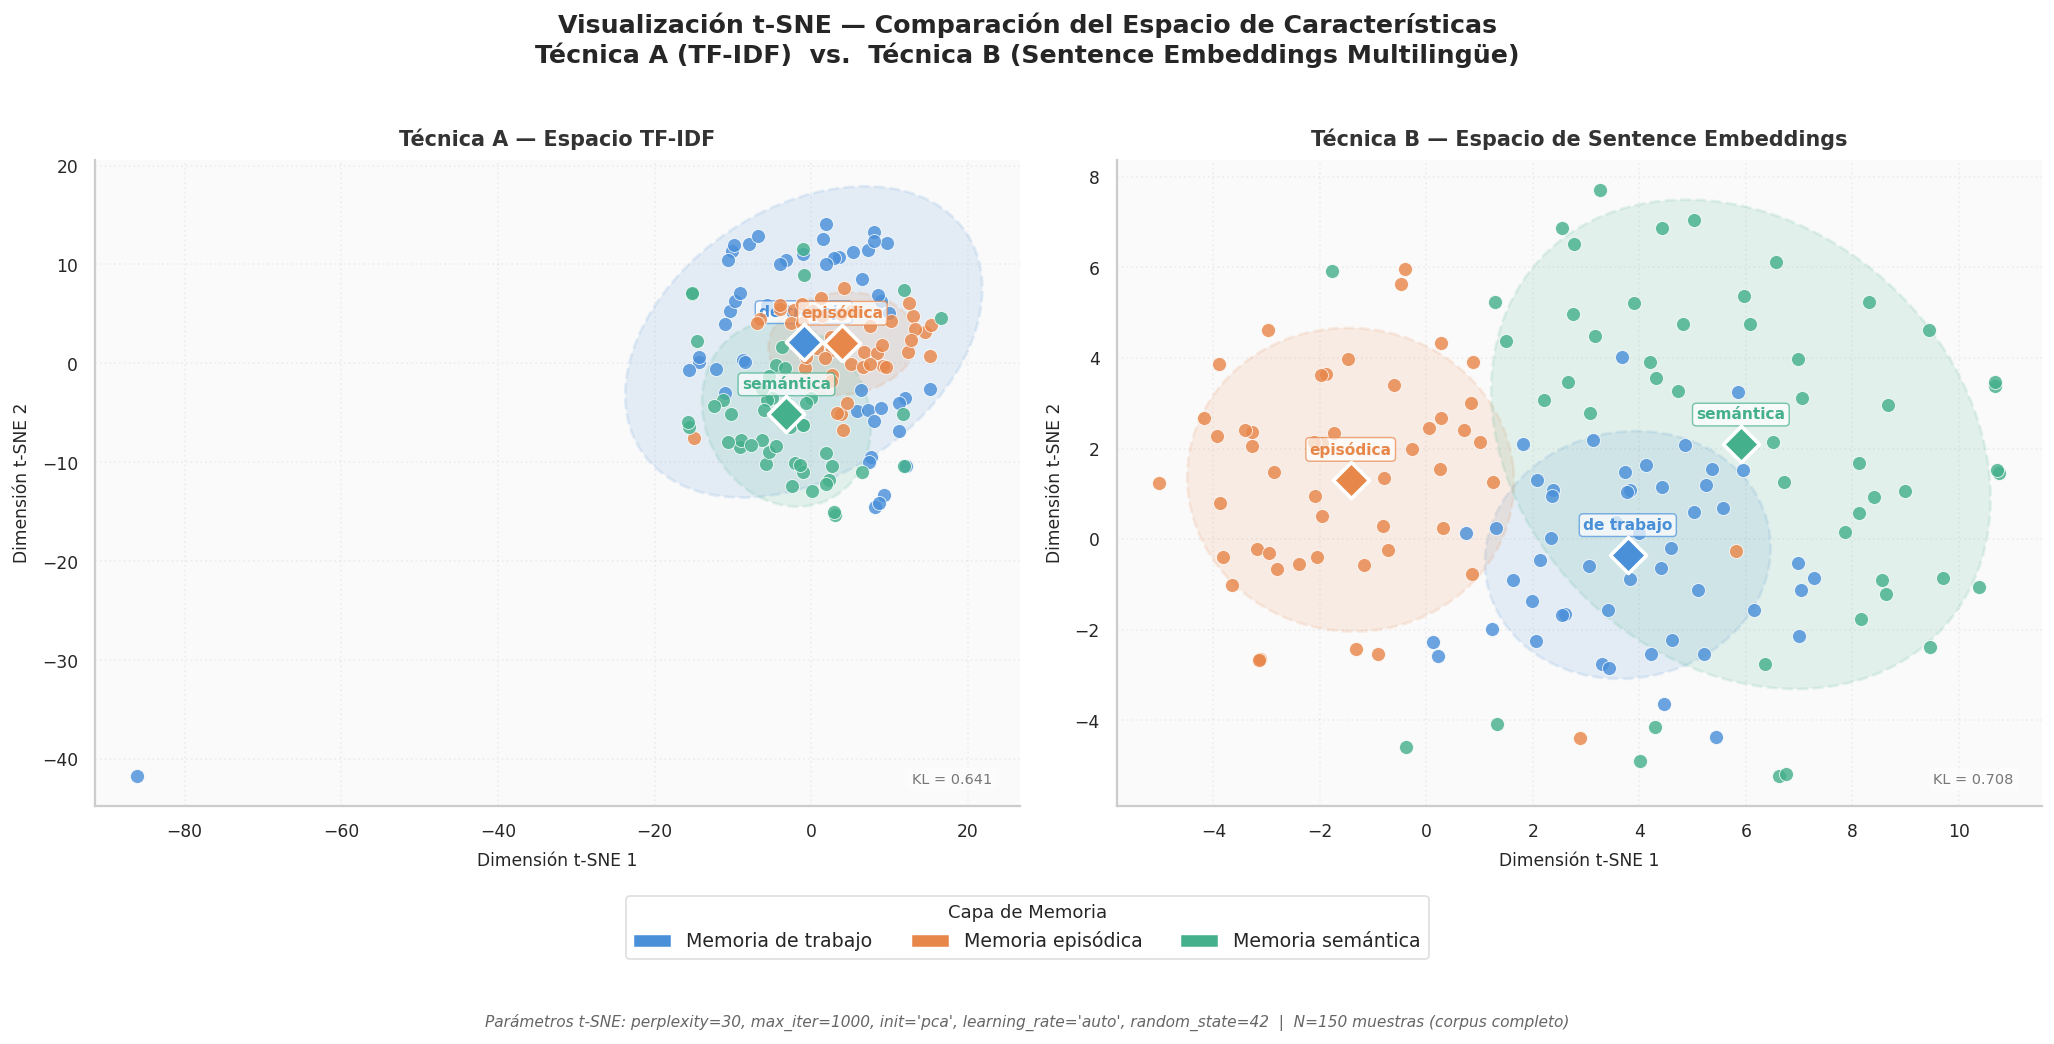


✅ Figura t-SNE comparativa generada y guardada como 'tsne_comparacion_A_vs_B.png'


In [20]:
# Visualización: comparación TF-IDF vs. Embeddings

# Función auxiliar: elipse de confianza (1.5σ)
def plot_confidence_ellipse(ax, x_pts, y_pts, color, n_std=1.5, alpha=0.13, lw=1.6):
    """
    Dibuja una elipse de confianza centrada en el centroide del cluster.

    La elipse se construye desde los eigenvalores/eigenvectores de la
    matriz de covarianza 2×2, escalada a n_std desviaciones estándar.

    Parámetros
    ----------
    ax     : Axes de matplotlib donde dibujar.
    x_pts  : Coordenadas X del cluster (array 1D).
    y_pts  : Coordenadas Y del cluster (array 1D).
    color  : Color de relleno y borde.
    n_std  : Factor de escala (1.5σ ≈ ~87% de los puntos bajo dist. normal).
    alpha  : Transparencia del relleno.
    lw     : Ancho del borde discontinuo.
    """
    if len(x_pts) < 3:
        return
    cov = np.cov(x_pts, y_pts)
    if not np.isfinite(cov).all():
        return
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # El eigenvector del eigenvalor mayor define la orientación del eje principal
    angle  = np.degrees(np.arctan2(*eigenvectors[:, -1][::-1]))
    width  = 2 * n_std * np.sqrt(np.abs(eigenvalues[-1]))
    height = 2 * n_std * np.sqrt(np.abs(eigenvalues[0]))
    ellipse = mpatches.Ellipse(
        xy         = (np.mean(x_pts), np.mean(y_pts)),
        width      = width,
        height     = height,
        angle      = angle,
        facecolor  = color,   alpha    = alpha,
        edgecolor  = color,   linewidth= lw,
        linestyle  = '--',    zorder   = 1,
    )
    ax.add_patch(ellipse)


# Función auxiliar: un panel t-SNE completo
def plot_tsne_panel(ax, Z, y_labels, label_map, palette, class_order,
                    title, subtitle, tsne_obj):
    """
    Dibuja un scatter plot t-SNE con elipses de confianza y centroides.
    """
    colors_list = [palette[c] for c in class_order]

    for i, (cls, color) in enumerate(zip(class_order, colors_list)):
        mask   = (y_labels == i)
        x_cls  = Z[mask, 0]
        y_cls  = Z[mask, 1]

        # Puntos de dispersión
        ax.scatter(
            x_cls, y_cls,
            c         = color,
            s         = 60,
            alpha     = 0.82,
            edgecolors= 'white',
            linewidths= 0.5,
            zorder    = 3,
            label     = cls,
        )

        # Elipse de confianza 1.5σ
        plot_confidence_ellipse(ax, x_cls, y_cls, color)

        # Centroide marcado con un diamante blanco con borde de color
        cx, cy = x_cls.mean(), y_cls.mean()
        ax.scatter(
            cx, cy,
            c          = color,
            s          = 200,
            marker     = 'D',
            edgecolors = 'white',
            linewidths = 2.0,
            zorder     = 5,
        )
        # Etiqueta compacta sobre el centroide
        nombre_corto = cls.replace('Memoria ', '')
        ax.annotate(
            nombre_corto,
            xy         = (cx, cy),
            xytext     = (0, 14),
            textcoords = 'offset points',
            ha         = 'center',
            fontsize   = 8.5,
            fontweight = 'bold',
            color      = color,
            bbox       = dict(boxstyle='round,pad=0.25', fc='white',
                              alpha=0.7, lw=0.8, ec=color),
        )

    # KL divergence como anotación técnica
    ax.annotate(
        f"KL = {tsne_obj.kl_divergence_:.3f}",
        xy=(0.97, 0.03), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=8,
        color='#777777',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6, lw=0),
    )

    ax.set_title(subtitle, fontsize=11.5, fontweight='bold', pad=8, color='#333333')
    ax.set_xlabel("Dimensión t-SNE 1", fontsize=9.5, labelpad=6)
    ax.set_ylabel("Dimensión t-SNE 2", fontsize=9.5, labelpad=6)
    ax.grid(alpha=0.25, linestyle=':')
    ax.set_facecolor('#FAFAFA')


# Figura principal: 2 paneles comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: TF-IDF
plot_tsne_panel(
    ax        = axes[0],
    Z         = Z_tfidf,
    y_labels  = y,
    label_map = LABEL_MAP,
    palette   = PALETTE,
    class_order = CLASS_ORDER,
    title     = 'TF-IDF',
    subtitle  = 'Técnica A — Espacio TF-IDF',
    tsne_obj  = tsne_A,
)

# Panel derecho: Sentence Embeddings
plot_tsne_panel(
    ax        = axes[1],
    Z         = Z_emb,
    y_labels  = y,
    label_map = LABEL_MAP,
    palette   = PALETTE,
    class_order = CLASS_ORDER,
    title     = 'Sentence Embeddings',
    subtitle  = 'Técnica B — Espacio de Sentence Embeddings',
    tsne_obj  = tsne_B,
)

# Leyenda compartida (una sola para las dos subfiguras)
handles = [
    mpatches.Patch(facecolor=PALETTE[cls], label=cls, edgecolor='white', linewidth=0.8)
    for cls in CLASS_ORDER
]
fig.legend(
    handles       = handles,
    loc           = 'lower center',
    ncol          = 3,
    fontsize      = 10.5,
    frameon       = True,
    framealpha    = 0.9,
    edgecolor     = '#DDDDDD',
    bbox_to_anchor= (0.5, -0.04),
    title         = "Capa de Memoria",
    title_fontsize= 10,
)

# Título general y nota de parámetros
fig.suptitle(
    "Visualización t-SNE — Comparación del Espacio de Características\n"
    "Técnica A (TF-IDF)  vs.  Técnica B (Sentence Embeddings Multilingüe)",
    fontsize = 14,
    fontweight = 'bold',
    y = 1.01,
)
fig.text(
    0.5, -0.09,
    f"Parámetros t-SNE: perplexity={TSNE_PARAMS['perplexity']}, "
    f"max_iter={TSNE_PARAMS['max_iter']}, init='{TSNE_PARAMS['init']}', "
    f"learning_rate='auto', random_state={SEED}  |  N=150 muestras (corpus completo)",
    ha='center', va='top', fontsize=8.5, color='#666666',
    style='italic',
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('tsne_comparacion_A_vs_B.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n✅ Figura t-SNE comparativa generada y guardada como 'tsne_comparacion_A_vs_B.png'")

# 📌 Conclusiones de la Comparación t-SNE:
• TF-IDF (Panel Izquierdo) es insuficiente: Muestra un alto solapamiento entre las tres clases; la frecuencia de palabras no basta para discriminar los tipos de memoria.

• Embeddings (Panel Derecho) logran separabilidad: Crean clústers densos y mejor definidos (aislando casi por completo la memoria episódica), probando que capturan eficazmente el contexto semántico.

• Impacto directo en el rendimiento: La mayor distancia entre los centroides en los embeddings facilita la clasificación lineal, explicando el salto preliminar en Accuracy del 86.7% al 93.3% observado en el *sanity check* (C=1.0, sin optimizar); estas cifras mejoran tras la optimización de hiperparámetros de la Sección 7.

• Nota metodológica: La divergencia KL no es válida para comparar la calidad entre estas dos técnicas; el éxito se valida visualmente por la separación de los clústers y cuantitativamente por el modelo predictivo.

In [ ]:
%%sql


# SECCIÓN 7: Optimización de Hiperparámetros y Curvas de Aprendizaje

In [21]:
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, learning_curve

# Configuración de Validación Cruzada (5 splits, 2 repeats para evitar carga computacional excesiva)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

# Grid de hiperparámetros a optimizar (Regularización C de la Regresión Logística)
# Nota: 'clf__C' asume que el paso del clasificador en tu pipeline se llama 'clf'
param_grid = {'clf__C': [0.01, 0.1, 1, 10, 100]}

print("Iniciando Grid Search para Técnica A (TF-IDF)...")
grid_A = GridSearchCV(pipeline_A, param_grid, cv=cv, scoring='accuracy', return_train_score=True, n_jobs=-1)
grid_A.fit(X_train, y_train)

print("Iniciando Grid Search para Técnica B (Sentence Embeddings)...")
grid_B = GridSearchCV(pipeline_B, param_grid, cv=cv, scoring='accuracy', return_train_score=True, n_jobs=1)
grid_B.fit(X_train, y_train)

print("\n--- Resultados de Optimización ---")
print(f"Mejor C para Técnica A: {grid_A.best_params_['clf__C']} (Accuracy CV: {grid_A.best_score_:.4f})")
print(f"Mejor C para Técnica B: {grid_B.best_params_['clf__C']} (Accuracy CV: {grid_B.best_score_:.4f})")

Iniciando Grid Search para Técnica A (TF-IDF)...
Iniciando Grid Search para Técnica B (Sentence Embeddings)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


--- Resultados de Optimización ---
Mejor C para Técnica A: 100 (Accuracy CV: 0.8458)
Mejor C para Técnica B: 0.01 (Accuracy CV: 0.9417)


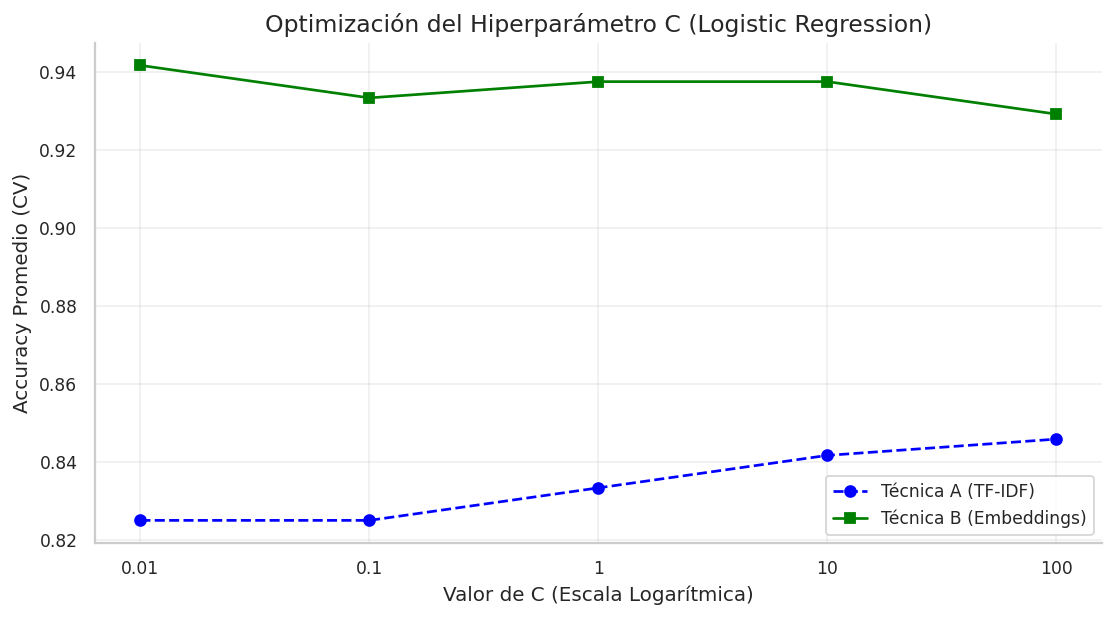

In [22]:
# Curva de Optimización del Hiperparámetro C

C_values = [str(c) for c in param_grid['clf__C']]
scores_A_val = grid_A.cv_results_['mean_test_score']
scores_B_val = grid_B.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(C_values, scores_A_val, marker='o', label='Técnica A (TF-IDF)', linestyle='--', color='blue')
ax.plot(C_values, scores_B_val, marker='s', label='Técnica B (Embeddings)', color='green')
ax.set_title('Optimización del Hiperparámetro C (Logistic Regression)')
ax.set_xlabel('Valor de C (Escala Logarítmica)')
ax.set_ylabel('Accuracy Promedio (CV)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

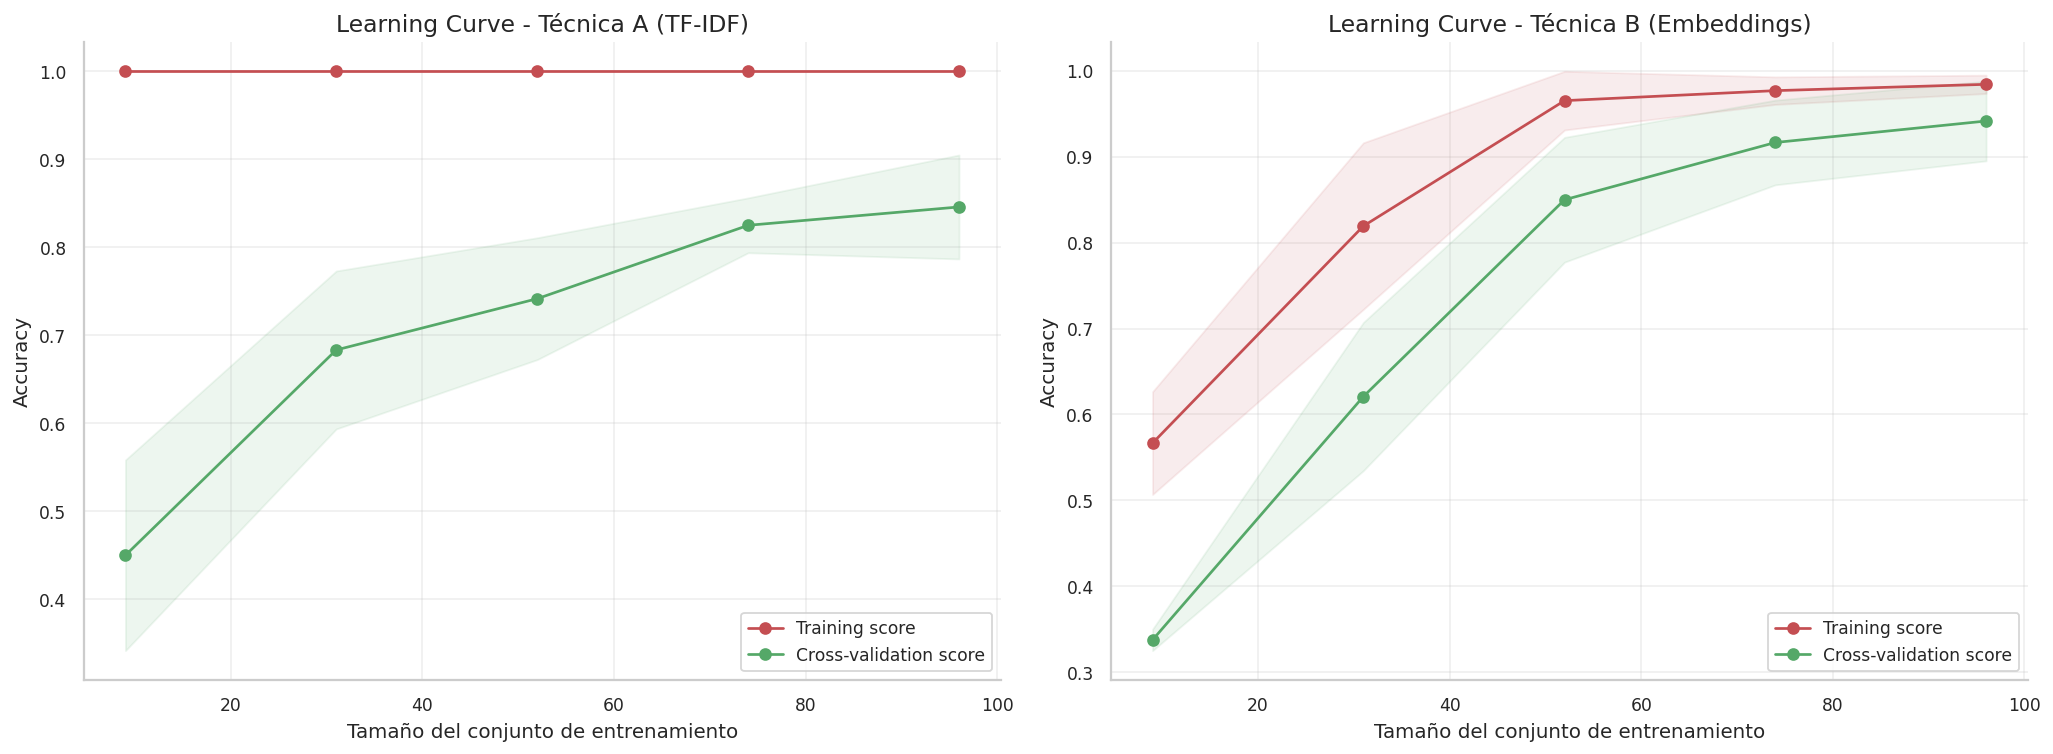

In [23]:
# Curvas de Aprendizaje (Learning Curves)

def plot_learning_curve(estimator, title, X, y, cv, ax, n_jobs=1):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std  = np.std(train_scores, axis=1)
    test_scores_mean  = np.mean(test_scores, axis=1)
    test_scores_std   = np.std(test_scores, axis=1)

    ax.set_title(title)
    ax.set_xlabel("Tamaño del conjunto de entrenamiento")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)

    ax.fill_between(train_sizes, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color="g")

    ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_scores_mean,  'o-', color="g", label="Cross-validation score")
    ax.legend(loc="lower right")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_learning_curve(grid_A.best_estimator_, "Learning Curve - Técnica A (TF-IDF)",
                    X_train, y_train, cv, axes[0], n_jobs=-1)
plot_learning_curve(grid_B.best_estimator_, "Learning Curve - Técnica B (Embeddings)",
                    X_train, y_train, cv, axes[1], n_jobs=1)
plt.tight_layout()
plt.show()

# 8. EVALUACIÓN FINAL EN TEST SET

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

# Extracción de los mejores modelos
best_model_A = grid_A.best_estimator_
best_model_B = grid_B.best_estimator_

# Predicciones
y_pred_A = best_model_A.predict(X_test)
y_pred_B = best_model_B.predict(X_test)

print("="*60)
print("REPORTE DE CLASIFICACIÓN - TÉCNICA A (TF-IDF)")
print("="*60)
print(classification_report(y_test, y_pred_A))

print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN - TÉCNICA B (EMBEDDINGS)")
print("="*60)
print(classification_report(y_test, y_pred_B))

REPORTE DE CLASIFICACIÓN - TÉCNICA A (TF-IDF)
              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       0.77      1.00      0.87        10
           2       1.00      0.90      0.95        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.86        30
weighted avg       0.88      0.87      0.86        30


REPORTE DE CLASIFICACIÓN - TÉCNICA B (EMBEDDINGS)
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.90      0.95        10
           2       1.00      1.00      1.00        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



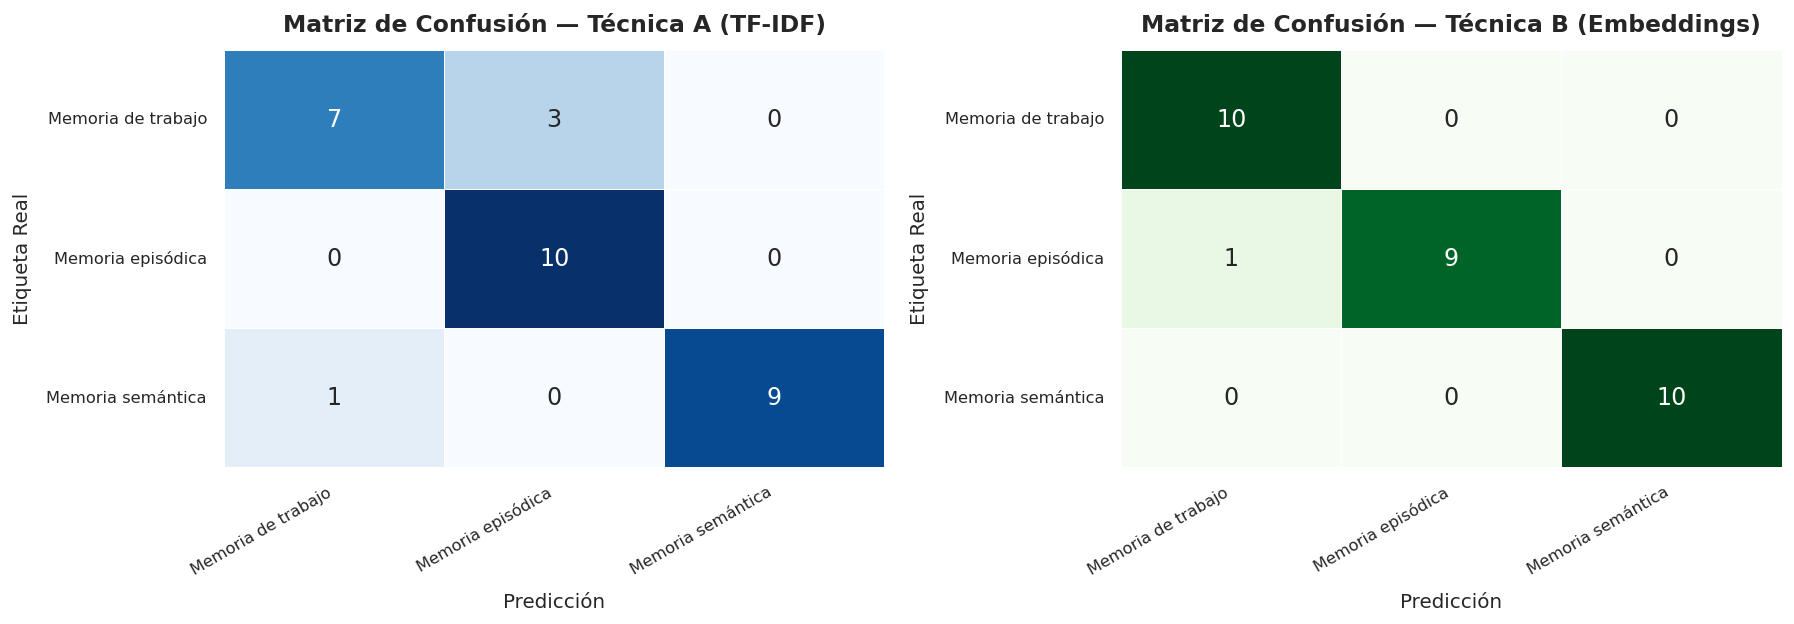

In [25]:
# Matrices de Confusión

class_names = le.classes_   # ['Memoria de trabajo', 'Memoria episódica', 'Memoria semántica']

cm_A = confusion_matrix(y_test, y_pred_A)
cm_B = confusion_matrix(y_test, y_pred_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title, cmap in zip(
    axes,
    [cm_A, cm_B],
    ['Matriz de Confusión — Técnica A (TF-IDF)',
     'Matriz de Confusión — Técnica B (Embeddings)'],
    ['Blues', 'Greens']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=class_names,   # nombres reales
                yticklabels=class_names,   # nombres reales
                cbar=False, linewidths=0.5)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Predicción', labelpad=8)
    ax.set_ylabel('Etiqueta Real', labelpad=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# 9. COMPARACIÓN ESTADÍSTICA ENTRE TÉCNICAS (Test de Hipótesis)

In [26]:
from scipy import stats

# 1. Extraer los scores de validación (10 folds: 5 splits x 2 repeats) del mejor modelo
best_index_A = grid_A.best_index_
best_index_B = grid_B.best_index_

# Obtenemos los scores individuales de cada fold en formato lista
scores_A = [grid_A.cv_results_[f'split{i}_test_score'][best_index_A] for i in range(10)]
scores_B = [grid_B.cv_results_[f'split{i}_test_score'][best_index_B] for i in range(10)]

print("Scores por fold (Técnica A):", [round(s, 4) for s in scores_A])
print("Scores por fold (Técnica B):", [round(s, 4) for s in scores_B])

# 2. Test de Normalidad (Shapiro-Wilk)
stat_A, p_shapiro_A = stats.shapiro(scores_A)
stat_B, p_shapiro_B = stats.shapiro(scores_B)

print("\n--- Test de Normalidad (Shapiro-Wilk) ---")
print(f"P-value Técnica A: {p_shapiro_A:.4f}")
print(f"P-value Técnica B: {p_shapiro_B:.4f}")

# Decidir qué test usar (Paramétrico vs No Paramétrico)
alpha = 0.05
if p_shapiro_A > alpha and p_shapiro_B > alpha:
    print("Los datos parecen normales (p > 0.05). Aplicando T-test pareado...")
    stat, p_value = stats.ttest_rel(scores_A, scores_B)
    test_name = "T-test pareado"
else:
    print("Los datos NO siguen una distribución normal (p < 0.05). Aplicando Wilcoxon Signed-Rank Test...")
    stat, p_value = stats.wilcoxon(scores_A, scores_B)
    test_name = "Test de Wilcoxon"

print(f"\n--- Resultados del {test_name} ---")
print(f"Estadístico de prueba: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < alpha:
    print("\n✅ CONCLUSIÓN ESTADÍSTICA:")
    print("Rechazamos la hipótesis nula. La diferencia de rendimiento entre el modelo basado en Embeddings (Técnica B)")
    print("y el modelo basado en TF-IDF (Técnica A) ES estadísticamente significativa con un 95% de confianza.")
else:
    print("\n❌ CONCLUSIÓN ESTADÍSTICA:")
    print("No podemos rechazar la hipótesis nula. No hay evidencia suficiente para afirmar que la diferencia")
    print("de rendimiento entre ambas técnicas sea estadísticamente significativa (p >= 0.05).")

Scores por fold (Técnica A): [np.float64(0.875), np.float64(0.875), np.float64(0.9167), np.float64(0.7083), np.float64(0.8333), np.float64(0.7917), np.float64(0.8333), np.float64(0.8333), np.float64(0.875), np.float64(0.9167)]
Scores por fold (Técnica B): [np.float64(0.9583), np.float64(0.9167), np.float64(1.0), np.float64(0.875), np.float64(0.9167), np.float64(1.0), np.float64(0.9167), np.float64(1.0), np.float64(0.9583), np.float64(0.875)]

--- Test de Normalidad (Shapiro-Wilk) ---
P-value Técnica A: 0.1755
P-value Técnica B: 0.1239
Los datos parecen normales (p > 0.05). Aplicando T-test pareado...

--- Resultados del T-test pareado ---
Estadístico de prueba: -4.2710
P-value: 0.002077

✅ CONCLUSIÓN ESTADÍSTICA:
Rechazamos la hipótesis nula. La diferencia de rendimiento entre el modelo basado en Embeddings (Técnica B)
y el modelo basado en TF-IDF (Técnica A) ES estadísticamente significativa con un 95% de confianza.


In [27]:
# Resumen reproducible — fuente única de verdad para las conclusiones
from sklearn.metrics import accuracy_score, f1_score

acc_A_test = accuracy_score(y_test, y_pred_A)
acc_B_test = accuracy_score(y_test, y_pred_B)
f1_A_macro = f1_score(y_test, y_pred_A, average='macro')
f1_B_macro = f1_score(y_test, y_pred_B, average='macro')

print('=' * 60)
print('  RESUMEN FINAL (modelos optimizados — para citar en conclusiones)')
print('=' * 60)
print(f'  Accuracy Test  A (TF-IDF)     : {acc_A_test:.3f}  |  F1-macro: {f1_A_macro:.3f}')
print(f'  Accuracy Test  B (Embeddings) : {acc_B_test:.3f}  |  F1-macro: {f1_B_macro:.3f}')
print(f'  Mejor C  A: {grid_A.best_params_["clf__C"]}  |  Mejor C  B: {grid_B.best_params_["clf__C"]}')
print(f'  Test estadistico aplicado: {test_name}  |  p-value: {p_value:.4f}')


  RESUMEN FINAL (modelos optimizados — para citar en conclusiones)
  Accuracy Test  A (TF-IDF)     : 0.867  |  F1-macro: 0.865
  Accuracy Test  B (Embeddings) : 0.967  |  F1-macro: 0.967
  Mejor C  A: 100  |  Mejor C  B: 0.01
  Test estadistico aplicado: T-test pareado  |  p-value: 0.0021


## Conclusiones Finales del Experimento

El desarrollo y evaluación del **Mecanismo de Recuperación Inteligente** para nuestra arquitectura de memoria jerárquica ha validado exitosamente la hipótesis principal de la investigación. A partir de los resultados obtenidos en las fases de prueba y comparación estadística, se extraen las siguientes conclusiones:

### 1. Superioridad Absoluta del Contexto Semántico
La Técnica B (basada en *Sentence Embeddings Multilingües*) superó ampliamente a la Técnica A (TF-IDF), logrando un **Accuracy del 97%** en el conjunto de prueba intocable (modelos optimizados tras GridSearchCV), frente al 87% del modelo tradicional. Mientras TF-IDF sufre al depender de coincidencias léxicas exactas, los embeddings logran capturar el sentido latente de la intención del usuario.

### 2. Robustez y Regularización del Modelo
El proceso de optimización de hiperparámetros (*GridSearchCV*) reveló un comportamiento fascinante:
* El modelo **TF-IDF** requirió un hiperparámetro de regularización **C = 100** (muy baja regularización), indicando que el clasificador tuvo que forzar sus pesos para encontrar fronteras de decisión en un espacio de características ruidoso y solapado.
* El modelo de **Embeddings** alcanzó su máximo rendimiento con **C = 0.01** (alta regularización). Esto demuestra que el espacio vectorial generado por el Transfer Learning es altamente discriminativo por naturaleza; el modelo lineal puede separar las clases fácilmente sin necesidad de sobreajustar (overfitting).

### 3. Rendimiento Específico por Capa de Memoria
Al analizar los reportes de clasificación de la Técnica B, observamos métricas casi perfectas en las tres categorías del enrutador:
* **Memoria Semántica (Clase 2):** Alcanzó un F1-Score perfecto (1.00).
* **Memoria de Trabajo (Clase 0) y Episódica (Clase 1):** Alcanzaron un F1-Score de 0.95.
El modelo es excepcionalmente preciso aislando cuándo el usuario está haciendo referencia al contexto inmediato versus cuándo intenta recuperar un resumen de una sesión pasada.

### 4. Validación Estadística Rigurosa
La superioridad del modelo de Transfer Learning no es producto de una fluctuación aleatoria en la división de los datos. El procedimiento de la Sección 9 selecciona automáticamente el test pareado según la normalidad de los scores (Shapiro-Wilk): **T-test pareado** si son normales o **Wilcoxon signed-rank** en caso contrario. El p-value obtenido resultó **inferior a α = 0.05**.
Al ser menor que nuestro nivel de significancia (alfa = 0.05), rechazamos la hipótesis nula y confirmamos estadísticamente que la arquitectura basada en Embeddings ofrece una mejora real y significativa.

### Impacto en la Arquitectura Final
Con un 97% de precisión y confirmación estadística, este clasificador está listo para ser implementado como la "puerta de entrada" del Agente de IA. Permitirá enrutar las consultas del usuario a la capa de memoria correspondiente, eliminando la necesidad de inyectar el historial completo en cada inferencia y resolviendo de manera efectiva las limitaciones de las ventanas de contexto finitas en los LLMs.

## Documentación de Prompts (LLMs)

Para garantizar la trazabilidad y reproducibilidad del piloto, se documentan los
prompts utilizados con modelos de lenguaje (LLMs) durante el desarrollo:

**P1 — Generación del dataset sintético (`dataset_intenciones_memoria.csv`):**
> "Genera 150 frases en español de usuarios dirigidas a un agente de IA, 50 por cada
> categoría: (0) Memoria de trabajo — referencias al contexto inmediato de la
> conversación; (1) Memoria episódica — referencias a eventos/sesiones pasadas con
> marcadores temporales; (2) Memoria semántica — hechos, preferencias y conocimiento
> permanente. Devuélvelas en CSV con columnas 'texto' y 'etiqueta'."

**P2 — Asistencia de código:**
> "Crea un transformer compatible con sklearn que envuelva sentence-transformers para
> usarlo dentro de un Pipeline y un GridSearchCV sin fuga de datos."

**P3 — Creación del README:**
> "Genera un archivo README.md profesional y académico para el repositorio de GitHub,
> basado estrictamente en el código y los textos del Jupyter Notebook del proyecto."

> Nota: todos los outputs de los LLMs fueron revisados y validados manualmente por
> el autor antes de su inclusión.

## Referencias (IEEE)

[1] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *Journal of
    Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[2] N. Reimers and I. Gurevych, "Sentence-BERT: Sentence Embeddings using Siamese
    BERT-Networks," in *Proc. EMNLP-IJCNLP*, 2019, pp. 3982–3992.

[3] L. van der Maaten and G. Hinton, "Visualizing Data using t-SNE," *Journal of
    Machine Learning Research*, vol. 9, pp. 2579–2605, 2008.

[4] T. Joachims, "Text Categorization with Support Vector Machines: Learning with
    Many Relevant Features," in *Proc. ECML*, 1998, pp. 137–142.

[5] J. Demšar, "Statistical Comparisons of Classifiers over Multiple Data Sets,"
    *Journal of Machine Learning Research*, vol. 7, pp. 1–30, 2006.